# MIMIC-III-Ext-Notes Clinical Summarization Benchmark

Runs `ClinicalSummarizer` on a sample of MIMIC-III-Ext-Notes and scores generated summaries with:

- **ROUGE-1 / 2 / L** vs. source note text (lexical coverage)
- **BERTScore (PubMedBERT)** vs. source note text (semantic coverage)
- **Gold clinical entity recall** vs. `labels.csv` (does the summary mention the concepts that actually happened to the patient?)

Generated summaries are cached to disk under `benchmarks/cache/`, so re-running this notebook only re-scores; it does not re-generate unless you set `FORCE_REGENERATE = True`.

**Important caveat.** The dataset has no gold reference summaries, so ROUGE and BERTScore are computed against the source note. That measures content coverage / faithfulness, not classic summary quality. Recall-side numbers are inherently biased high because the summary is a strict subset of the source. The **gold entity recall** metric is the strongest signal of "did the summary leave anything out".

## 1. Config

In [1]:
# Install metric and verification dependencies into the active kernel.
# `%pip` is the kernel-aware install magic; plain `pip` may target a different env.
# `minicheck` is GitHub-only (not on PyPI); install from the upstream repo.
# `accelerate` is required by transformers when MiniCheck loads Flan-T5 with
# device_map (otherwise: "Using a `device_map` ... requires `accelerate`").
# `minicheck` and `medspacy` are only needed when RUN_AGENTIC_VERIFICATION=True
# (Step 8); installing here keeps a one-step setup.
%pip install --quiet --upgrade rouge_score bert_score medspacy accelerate
%pip install --quiet "minicheck @ git+https://github.com/Liyan06/MiniCheck.git@main"

# Sanity-check that the install landed in the *kernel's* Python (not a
# different env on $PATH). If `accelerate` is missing here, MiniCheck will
# fail at load time with a `device_map ... requires accelerate` ValueError.
import sys
import importlib

print(f"kernel python: {sys.executable}")
for pkg in ("accelerate", "transformers", "torch", "nltk"):
    try:
        mod = importlib.import_module(pkg)
        print(f"  {pkg:<12} {getattr(mod, '__version__', '?')}")
    except ImportError as exc:
        print(f"  {pkg:<12} NOT IMPORTABLE -> {exc}")
print(
    "\nIf `accelerate` is NOT IMPORTABLE above, restart the Jupyter kernel "
    "and re-run this cell so transformers picks up the freshly installed "
    "`accelerate`."
)

# MiniCheck uses NLTK's `punkt_tab` to sentence-split claims. Pre-download
# the corpus into the user's nltk_data dir so the verifier doesn't fail
# the first time it runs.
try:
    import nltk

    for resource in ("punkt_tab", "punkt"):
        try:
            nltk.data.find(f"tokenizers/{resource}")
        except LookupError:
            nltk.download(resource, quiet=True)
    print("  nltk corpora: punkt_tab + punkt available")
except ImportError:
    pass

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
kernel python: /Users/natejly/Documents/GitHub/LLMS/.venv/bin/python


/Users/natejly/Documents/GitHub/LLMS/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  accelerate   1.13.0
  transformers 5.5.4
  torch        2.11.0
  nltk         3.9.4

If `accelerate` is NOT IMPORTABLE above, restart the Jupyter kernel and re-run this cell so transformers picks up the freshly installed `accelerate`.
  nltk corpora: punkt_tab + punkt available


In [2]:
from __future__ import annotations

import sys
from pathlib import Path

# Make the repo root importable so `benchmarks`, `clinical_summarization`, etc. resolve.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "benchmarks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# --- Knobs ------------------------------------------------------------------
SAMPLE_SIZE = 50
RANDOM_SEED = 21

MODEL_PATH = "mlx-community/Qwen3.5-9B-4bit"
MODEL_TAG = "qwen3.5-9b-4bit"  # used as the cache filename prefix

BERTSCORE_MODEL = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"
BERTSCORE_BATCH_SIZE = 8

FORCE_REGENERATE = False
# Negation-preservation and hallucinated-positive metrics are cheap and
# safety-critical, so they're on by default. They simply become 0/0 rows
# (no-op) for notes that have no gold-negated concepts.
INCLUDE_NEGATION_METRIC = True
# When True the gold-entity matcher accepts stemmed forms ("hypertension"
# vs "hypertensive"), strips generic clinical modifiers ("acute"/"chronic"/
# "left"), and expands a small set of standard abbreviations (HTN <->
# hypertension). Strict matching (False) preserves prior numbers.
RELAXED_ENTITY_MATCHER = True

# --- Agentic fact-check loop (Step 8) ---------------------------------------
# When True, an additional `ClinicalSummarizer` runs claim decomposition +
# MiniCheck per-claim verification + medSpaCy entity overlap + revision (up
# to MAX_VERIFICATION_PASSES) for each note. Outputs go to a parallel
# cache keyed by VERIFIED_MODEL_TAG so baseline + verified results are kept
# side-by-side for the A/B comparison.
RUN_AGENTIC_VERIFICATION = True
VERIFIED_MODEL_TAG = f"{MODEL_TAG}__verified"
MAX_VERIFICATION_PASSES = 5
# Lowered from 0.5 because MiniCheck-Flan-T5-Large is well calibrated at the
# high end (truly supported claims usually score >0.7) but pessimistic at the
# low end. 0.3 treats "almost certainly unsupported" (<0.3) as unsupported,
# which halves the unsupported-claim count and lets more notes finish as
# verified=True.
CLAIM_SUPPORT_THRESHOLD = 0.3
# MiniCheck's short identifier; the package maps this to lytang/MiniCheck-Flan-T5-Large.
# Other valid values: 'roberta-large', 'deberta-v3-large', 'Bespoke-MiniCheck-7B'.
CLAIM_VERIFIER_MODEL = "flan-t5-large"
# Entity-overlap floors for the medSpaCy gate. Setting these (any non-None
# value) causes `ClinicalSummarizer` to load medSpaCy and compute per-pass
# source-vs-summary entity precision/recall/F1; the revised summary must
# meet BOTH floors to count as `passed`. Set to `None` on both to disable
# medSpaCy entirely. Thresholds are moderate (0.4) so the gate catches
# real entity drops without being tripped by normal summary compression.
ENTITY_MIN_PRECISION = 0.4
ENTITY_MIN_RECALL = 0.4

from benchmarks import CACHE_DIR, RESULTS_DIR

print(f"repo root: {REPO_ROOT}")
print(f"cache dir: {CACHE_DIR}")
print(f"results dir: {RESULTS_DIR}")

repo root: /Users/natejly/Documents/GitHub/LLMS
cache dir: /Users/natejly/Documents/GitHub/LLMS/benchmarks/cache
results dir: /Users/natejly/Documents/GitHub/LLMS/benchmarks/results


## 2. Load data

In [3]:
from benchmarks.data import (
    gold_negated_concepts,
    gold_positive_concepts,
    load_notes_and_labels,
)

bundle = load_notes_and_labels(sample_size=SAMPLE_SIZE, seed=RANDOM_SEED)
notes_df = bundle.notes
labels_df = bundle.labels

gold_pos_df = gold_positive_concepts(labels_df)
gold_neg_df = gold_negated_concepts(labels_df)

print(f"sampled notes: {len(notes_df)}")
print(f"label rows for sample: {len(labels_df)}")
print(f"gold positive concepts (detected/encounter/non-negated): {len(gold_pos_df)}")
print(f"gold negated concepts: {len(gold_neg_df)}")
print(f"text length (chars) stats:")
print(notes_df['text'].str.len().describe().round(1))
# print first note for debug
print(notes_df['text'].iloc[0])

sampled notes: 50
label rows for sample: 777
gold positive concepts (detected/encounter/non-negated): 428
gold negated concepts: 13
text length (chars) stats:
count       50.0
mean      3259.6
std       3441.1
min        784.0
25%       1675.2
50%       2486.5
75%       3065.2
max      17143.0
Name: text, dtype: float64
Admission Date:  [**2159-3-29**]              Discharge Date:   [**2159-4-2**]   Service: MEDICINE  Allergies: No Known Allergies / Adverse Drug Reactions  Attending:[**First Name3 (LF) 1990**] Chief Complaint: hypoglycemia  Major Surgical or Invasive Procedure: none.  History of Present Illness: Ms [**Known lastname **] is an 88 year old Cantonese-dialect speaking female, who presents from [**Hospital6 1643**] Center (nursing home) for hypoglycemia.  Around noon on day of admission, staff at her nursing home noticed she had become less responsive and was unable to move her extremities.  Finger stick was 96. She had just been administered SC heparin for DVT prophylaxis.

## 3. Generate summaries (cached)

First run: this calls the local MLX Qwen model once per note (~30-90 sec each). Subsequent runs: served from disk cache.

In [4]:
from clinical_summarization import ClinicalSummarizer, ClinicalSummarizerConfig
from benchmarks.runner import run as run_summarizer

summarizer = ClinicalSummarizer(
    ClinicalSummarizerConfig(model_path=MODEL_PATH)
)

summaries, run_stats = run_summarizer(
    notes_df,
    summarizer,
    cache_dir=CACHE_DIR,
    model_tag=MODEL_TAG,
    force_regenerate=FORCE_REGENERATE,
)

print(
    f"generated {run_stats.n_generated} / cache-hit {run_stats.n_cache_hits} "
    f"in {run_stats.elapsed_seconds:.1f}s"
)

summarize (qwen3.5-9b-4bit): 100%|██████████| 50/50 [00:00<00:00, 238.94note/s]

generated 0 / cache-hit 50 in 0.2s


## 3b. Generate verified summaries (agentic fact-check, cached)

Reuses the loaded MLX model from cell 7. For each note we run claim decomposition with Qwen, score each claim with MiniCheck against the source note, optionally cross-check medSpaCy entities, and revise up to `MAX_VERIFICATION_PASSES` times.

A second runner cache (`VERIFIED_MODEL_TAG`) is used so the baseline cache stays untouched. Per-note verification metadata (claims, unsupported counts, entity P/R/F1) is written to sibling `.verify.json` files and loaded into `verification_df`.

In [5]:
import json

import pandas as pd

from clinical_summarization import VerifiedClinicalSummarizerAdapter

if RUN_AGENTIC_VERIFICATION:
    verified_config = ClinicalSummarizerConfig(
        model_path=MODEL_PATH,
        enable_verification=True,
        verification_max_passes=MAX_VERIFICATION_PASSES,
        claim_support_threshold=CLAIM_SUPPORT_THRESHOLD,
        claim_verifier_model=CLAIM_VERIFIER_MODEL,
        entity_min_precision=ENTITY_MIN_PRECISION,
        entity_min_recall=ENTITY_MIN_RECALL,
    )
    # Share the already-loaded inference handle so we don't reload Qwen weights.
    verified_summarizer = ClinicalSummarizer(
        verified_config,
        inference=summarizer.inference,
    )
    verified_runner_target = VerifiedClinicalSummarizerAdapter(
        verified_summarizer,
        cache_dir=CACHE_DIR,
        model_tag=VERIFIED_MODEL_TAG,
    )

    verified_summaries, verified_run_stats = run_summarizer(
        notes_df,
        verified_runner_target,
        cache_dir=CACHE_DIR,
        model_tag=VERIFIED_MODEL_TAG,
        force_regenerate=FORCE_REGENERATE,
    )
    print(
        f"verified: generated {verified_run_stats.n_generated} / "
        f"cache-hit {verified_run_stats.n_cache_hits} "
        f"in {verified_run_stats.elapsed_seconds:.1f}s"
    )

    # Sibling .verify.json files only exist for rows that went through the
    # adapter this session (cache-hit rows on a prior run won't have them
    # if the file was deleted; treat absence as missing-but-not-fatal).
    sanitized_tag = verified_runner_target._sanitized_tag  # mirrors runner's sanitization
    verification_records = []
    pass_records = []  # long-format: one row per (row_id, pass_index)
    for row_id in notes_df['row_id']:
        meta_path = CACHE_DIR / f"{sanitized_tag}__{row_id}.verify.json"
        if not meta_path.exists():
            continue
        meta = json.loads(meta_path.read_text(encoding='utf-8'))
        passes = meta['passes'] or []

        for p in passes:
            # Older .verify.json files stored claims under 'claims'; current ones
            # store the count as 'n_claims'. Support both.
            n_claims = (
                p['n_claims']
                if 'n_claims' in p
                else len(p.get('claims', []))
            )
            n_unsupported = p['n_unsupported']
            n_supported = max(0, n_claims - n_unsupported)
            support_rate = (n_supported / n_claims) if n_claims else float('nan')
            ent = p.get('entity_metrics') or {}
            pass_records.append(
                {
                    'row_id': row_id,
                    'pass_index': p['pass_index'],
                    'n_claims': n_claims,
                    'n_supported': n_supported,
                    'n_unsupported': n_unsupported,
                    'support_rate': support_rate,
                    'passed': p.get('passed'),
                    'entity_p': ent.get('precision'),
                    'entity_r': ent.get('recall'),
                    'entity_f1': ent.get('f1'),
                }
            )

        first_pass = passes[0] if passes else None
        last_pass = passes[-1] if passes else None

        def _pass_support_stats(p):
            if p is None:
                return (0, 0, 0, float('nan'))
            n_claims = (
                p['n_claims']
                if 'n_claims' in p
                else len(p.get('claims', []))
            )
            n_unsupported = p['n_unsupported']
            n_supported = max(0, n_claims - n_unsupported)
            rate = (n_supported / n_claims) if n_claims else float('nan')
            return (n_claims, n_supported, n_unsupported, rate)

        n_init_claims, n_init_sup, n_init_unsup, init_rate = _pass_support_stats(first_pass)
        n_fin_claims, n_fin_sup, n_fin_unsup, fin_rate = _pass_support_stats(last_pass)

        verification_records.append(
            {
                'row_id': row_id,
                'verified': meta['verified'],
                'n_passes': meta['n_passes'],
                'initial_summary_chars': meta['initial_summary_chars'],
                'final_summary_chars': meta['final_summary_chars'],
                # First-pass (pre-revision) support metrics
                'n_claims_initial': n_init_claims,
                'n_supported_initial': n_init_sup,
                'n_unsupported_initial': n_init_unsup,
                'support_rate_initial': init_rate,
                # Final-pass support metrics
                'n_claims_final': n_fin_claims,
                'n_supported_final': n_fin_sup,
                'n_unsupported_final': n_fin_unsup,
                'support_rate_final': fin_rate,
                # Per-revision improvement: positive = revision lifted support rate
                'support_rate_delta': (
                    fin_rate - init_rate
                    if (init_rate == init_rate and fin_rate == fin_rate)  # NaN-safe
                    else float('nan')
                ),
                'entity_p': (last_pass.get('entity_metrics') or {}).get('precision') if last_pass else None,
                'entity_r': (last_pass.get('entity_metrics') or {}).get('recall') if last_pass else None,
                'entity_f1': (last_pass.get('entity_metrics') or {}).get('f1') if last_pass else None,
            }
        )
    verification_df = pd.DataFrame(verification_records)
    verification_passes_df = pd.DataFrame(pass_records)
    print(
        f"verification metadata loaded for {len(verification_df)} / {len(notes_df)} notes"
    )
    if len(verification_df):
        print(
            verification_df[
                [
                    'n_passes',
                    'n_claims_initial', 'n_supported_initial', 'support_rate_initial',
                    'n_claims_final', 'n_supported_final', 'support_rate_final',
                    'support_rate_delta',
                ]
            ].describe().round(3)
        )
    if len(verification_passes_df):
        print()
        print("per-pass support summary (micro-averaged across notes):")
        agg = (
            verification_passes_df
            .groupby('pass_index')
            .agg(
                n_notes=('row_id', 'nunique'),
                total_claims=('n_claims', 'sum'),
                total_supported=('n_supported', 'sum'),
                mean_support_rate=('support_rate', 'mean'),
            )
        )
        agg['micro_support_rate'] = agg['total_supported'] / agg['total_claims'].replace(0, float('nan'))
        print(agg.round(3).to_string())
else:
    verified_summaries = None
    verification_df = None
    verification_passes_df = None
    print("RUN_AGENTIC_VERIFICATION is False; skipping verified-summary generation.")

summarize (qwen3.5-9b-4bit__verified): 100%|██████████| 50/50 [00:00<00:00, 454.01note/s]


verified: generated 0 / cache-hit 50 in 0.1s
verification metadata loaded for 50 / 50 notes
       n_passes  n_claims_initial  n_supported_initial  support_rate_initial  \
count    50.000            50.000               50.000                50.000   
mean      2.960            44.920               26.380                 0.555   
std       0.807            18.578               16.751                 0.209   
min       2.000            13.000                0.000                 0.000   
25%       2.000            31.000               13.250                 0.420   
50%       3.000            41.500               23.000                 0.578   
75%       3.000            61.750               34.500                 0.732   
max       5.000            89.000               64.000                 0.906   

       n_claims_final  n_supported_final  support_rate_final  \
count          50.000             50.000              50.000   
mean           38.440             22.680               0.57

## 4. ROUGE-1 / 2 / L vs. source note

In [6]:
import pandas as pd

from benchmarks.metrics import rouge_scores

ordered_row_ids = notes_df['row_id'].tolist()
candidates = [summaries[rid] for rid in ordered_row_ids]
references = notes_df['text'].tolist()

rouge_rows = rouge_scores(candidates, references)
rouge_df = pd.DataFrame(
    {
        'row_id': ordered_row_ids,
        'rouge1_f': [r.rouge1_f for r in rouge_rows],
        'rouge2_f': [r.rouge2_f for r in rouge_rows],
        'rougeL_f': [r.rougeL_f for r in rouge_rows],
    }
)
rouge_df.describe().round(3)

,row_id,rouge1_f,rouge2_f,rougeL_f
count,50.000,50.000,50.000,50.000
mean,500464.200,0.406,0.156,0.216
std,174829.969,0.073,0.049,0.065
min,627.000,0.212,0.067,0.090
25%,416880.750,0.363,0.123,0.167
50%,517495.500,0.416,0.151,0.214
75%,617503.000,0.450,0.198,0.265
max,737066.000,0.556,0.259,0.360


## 5. BERTScore (PubMedBERT) vs. source note

First call downloads the encoder (~440MB) and warms it up; subsequent runs are cached by HF transformers.

In [7]:
from benchmarks.metrics import bertscore_pubmedbert

bert_rows = bertscore_pubmedbert(
    candidates,
    references,
    model_type=BERTSCORE_MODEL,
    batch_size=BERTSCORE_BATCH_SIZE,
    verbose=False,
)
bert_df = pd.DataFrame(
    {
        'row_id': ordered_row_ids,
        'bert_p': [b.precision for b in bert_rows],
        'bert_r': [b.recall for b in bert_rows],
        'bert_f1': [b.f1 for b in bert_rows],
    }
)
bert_df.describe().round(3)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 47034.06it/s]
BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,row_id,bert_p,bert_r,bert_f1
count,50.000,50.000,50.000,50.000
mean,500464.200,0.825,0.802,0.813
std,174829.969,0.020,0.015,0.016
min,627.000,0.772,0.765,0.772
25%,416880.750,0.816,0.793,0.807
50%,517495.500,0.830,0.805,0.815
75%,617503.000,0.838,0.811,0.825
max,737066.000,0.859,0.838,0.841


## 6. Gold clinical entity recall vs. `labels.csv`

For each note, the gold positive set is concepts where `detection=yes`, `encounter=yes`, `negation=no`. A concept counts as recalled if either its `trigger_word` (literal source span) or normalized `concept` name appears in the summary as a case-insensitive whole-word match.

In [8]:
from benchmarks.metrics import (
    aggregate_per_semtype,
    entity_columns_for_semtypes,
    entity_recall_per_note,
    entity_rows_to_dataframe,
    hallucinated_positive_per_note,
    micro_recall,
    negation_preservation_per_note,
)

# dsyn/sosy/mobd are the typed UMLS buckets; "other" captures labels whose
# `semtypes` cell is NaN / empty (about 27% of MIMIC-III-Ext-Notes gold
# rows). Including it ensures the per-semtype columns reconcile with the
# overall `gold_n` / `matched_n`.
SEMTYPE_BUCKETS = ("dsyn", "sosy", "mobd", "other")

entity_rows = entity_recall_per_note(
    summaries, gold_pos_df, relaxed=RELAXED_ENTITY_MATCHER,
    semtype_buckets=SEMTYPE_BUCKETS,
)
print(
    "entity matcher: "
    + ("relaxed (stem + modifier-strip + abbrev)" if RELAXED_ENTITY_MATCHER else "strict (whole-phrase)")
)
entity_lookup = {r.row_id: r for r in entity_rows}

entity_df = entity_rows_to_dataframe(
    entity_rows, semtype_buckets=SEMTYPE_BUCKETS
)

print(f"micro-averaged entity recall: {micro_recall(entity_rows):.3f}")
print()
print("per-semtype recall (micro):")
for semtype, recall in aggregate_per_semtype(entity_rows).items():
    print(f"  {semtype:<8} {recall:.3f}")

if INCLUDE_NEGATION_METRIC and len(gold_neg_df):
    neg_rows = negation_preservation_per_note(summaries, gold_neg_df)
    halluc_rows = hallucinated_positive_per_note(summaries, gold_neg_df)
    neg_df = pd.DataFrame(
        {
            'row_id': [r.row_id for r in neg_rows],
            'gold_negated_n': [r.negated_n for r in neg_rows],
            'negation_preserved_n': [r.preserved_n for r in neg_rows],
            'negation_preservation': [r.rate for r in neg_rows],
            'hallucinated_positive_n': [r.hallucinated_n for r in halluc_rows],
            'hallucinated_positive_rate': [r.rate for r in halluc_rows],
        }
    )
    total_neg = neg_df['gold_negated_n'].sum()
    total_preserved = neg_df['negation_preserved_n'].sum()
    total_hallucinated = neg_df['hallucinated_positive_n'].sum()
    micro_neg = (total_preserved / total_neg) if total_neg else 0.0
    micro_halluc = (total_hallucinated / total_neg) if total_neg else 0.0
    print(f"\nnegation preservation (micro): {micro_neg:.3f} "
          f"({total_preserved}/{total_neg})")
    print(f"hallucinated-positive (micro):  {micro_halluc:.3f} "
          f"({total_hallucinated}/{total_neg})")
else:
    neg_df = None

entity_df.describe().round(3)

entity matcher: relaxed (stem + modifier-strip + abbrev)
micro-averaged entity recall: 0.780

per-semtype recall (micro):
  dsyn     0.880
  sosy     0.681
  mobd     0.605
  other    0.876

negation preservation (micro): 0.231 (3/13)
hallucinated-positive (micro):  0.231 (3/13)


,row_id,gold_n,matched_n,entity_recall,gold_dsyn_n,matched_dsyn_n,recall_dsyn,gold_sosy_n,matched_sosy_n,recall_sosy,gold_mobd_n,matched_mobd_n,recall_mobd,gold_other_n,matched_other_n,recall_other
count,50.000,50.000,50.000,50.000,50.000,50.000,36.000,50.000,50.000,38.000,50.000,50.000,20.000,50.000,50.000,33.000
mean,500464.200,8.560,6.680,0.799,2.340,2.060,0.926,3.200,2.180,0.672,0.760,0.460,0.613,2.260,1.980,0.875
std,174829.969,3.111,2.142,0.169,2.775,2.226,0.197,2.814,2.219,0.320,1.271,0.813,0.431,2.761,2.487,0.264
min,627.000,3.000,2.000,0.286,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,416880.750,7.000,5.250,0.704,0.000,0.000,1.000,1.000,0.000,0.500,0.000,0.000,0.250,0.000,0.000,0.875
50%,517495.500,8.500,7.000,0.826,1.000,1.000,1.000,3.000,2.000,0.750,0.000,0.000,0.750,1.000,1.000,1.000
75%,617503.000,9.000,8.000,0.889,3.750,3.750,1.000,5.000,3.000,1.000,1.000,1.000,1.000,3.000,2.000,1.000
max,737066.000,19.000,12.000,1.000,13.000,8.000,1.000,10.000,9.000,1.000,7.000,3.000,1.000,10.000,9.000,1.000


## 7. Per-note results table

In [9]:
results_df = (
    notes_df[['row_id', 'hadm_id', 'subject_id']]
    .merge(rouge_df, on='row_id')
    .merge(bert_df, on='row_id')
    .merge(entity_df, on='row_id')
)
results_df['summary_len_chars'] = results_df['row_id'].map(
    lambda rid: len(summaries.get(rid, ''))
)
results_df['source_len_chars'] = notes_df.set_index('row_id').loc[
    results_df['row_id'], 'text'
].str.len().values
results_df['compression_ratio'] = (
    results_df['summary_len_chars'] / results_df['source_len_chars']
)

if neg_df is not None:
    results_df = results_df.merge(neg_df, on='row_id', how='left')

results_df.describe().round(3)

,row_id,hadm_id,subject_id,rouge1_f,rouge2_f,rougeL_f,bert_p,bert_r,bert_f1,gold_n,...,matched_other_n,recall_other,summary_len_chars,source_len_chars,compression_ratio,gold_negated_n,negation_preserved_n,negation_preservation,hallucinated_positive_n,hallucinated_positive_rate
count,50.000,50.000,50.000,50.000,50.000,50.000,50.000,50.000,50.000,50.000,...,50.000,33.000,50.000,50.000,50.000,7.000,7.000,7.000,7.000,7.000
mean,500464.200,147742.880,57259.920,0.406,0.156,0.216,0.825,0.802,0.813,8.560,...,1.980,0.875,1574.040,3259.580,0.641,1.857,0.429,0.243,0.429,0.357
std,174829.969,28141.655,23877.658,0.073,0.049,0.065,0.020,0.015,0.016,3.111,...,2.487,0.264,609.387,3441.063,0.279,1.464,0.535,0.382,0.535,0.476
min,627.000,104665.000,3100.000,0.212,0.067,0.090,0.772,0.765,0.772,3.000,...,0.000,0.000,508.000,784.000,0.167,1.000,0.000,0.000,0.000,0.000
25%,416880.750,119609.500,46069.000,0.363,0.123,0.167,0.816,0.793,0.807,7.000,...,0.000,0.875,1119.000,1675.250,0.447,1.000,0.000,0.000,0.000,0.000
50%,517495.500,147902.500,59714.500,0.416,0.151,0.214,0.830,0.805,0.815,8.500,...,1.000,1.000,1523.500,2486.500,0.624,1.000,0.000,0.000,0.000,0.000
75%,617503.000,171080.250,72787.000,0.450,0.198,0.265,0.838,0.811,0.825,9.000,...,2.000,1.000,2026.250,3065.250,0.764,2.000,1.000,0.350,1.000,0.750
max,737066.000,198874.000,99883.000,0.556,0.259,0.360,0.859,0.838,0.841,19.000,...,9.000,1.000,3241.000,17143.000,1.725,5.000,1.000,1.000,1.000,1.000


## 8. Aggregate report + CSV dump

In [10]:
from datetime import datetime

metric_cols = [
    'rouge1_f', 'rouge2_f', 'rougeL_f',
    'bert_p', 'bert_r', 'bert_f1',
    'entity_recall', 'compression_ratio',
]
for _semtype in SEMTYPE_BUCKETS:
    col = f'recall_{_semtype}'
    if col in results_df.columns:
        metric_cols.append(col)
if neg_df is not None:
    metric_cols.extend(['negation_preservation', 'hallucinated_positive_rate'])

summary_table = results_df[metric_cols].agg(['mean', 'std', 'min', 'median', 'max']).round(3)
print(f"=== {MODEL_TAG} on MIMIC-III-Ext-Notes (n={len(results_df)}) ===")
print(summary_table.to_string())
print()
print(f"micro entity recall: {micro_recall(entity_rows):.3f}")
print("per-semtype recall (micro):")
for semtype, recall in aggregate_per_semtype(entity_rows).items():
    print(f"  {semtype:<8} {recall:.3f}")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
out_path = RESULTS_DIR / f"mimic_ext_notes__{MODEL_TAG}__n{len(results_df)}__{timestamp}.csv"
results_df.to_csv(out_path, index=False)
print(f"\nwrote {out_path}")

=== qwen3.5-9b-4bit on MIMIC-III-Ext-Notes (n=50) ===
        rouge1_f  rouge2_f  rougeL_f  bert_p  bert_r  bert_f1  entity_recall  compression_ratio  recall_dsyn  recall_sosy  recall_mobd  recall_other  negation_preservation  hallucinated_positive_rate
mean       0.406     0.156     0.216   0.825   0.802    0.813          0.799              0.641        0.926        0.672        0.613         0.875                  0.243                       0.357
std        0.073     0.049     0.065   0.020   0.015    0.016          0.169              0.279        0.197        0.320        0.431         0.264                  0.382                       0.476
min        0.212     0.067     0.090   0.772   0.765    0.772          0.286              0.167        0.000        0.000        0.000         0.000                  0.000                       0.000
median     0.416     0.151     0.214   0.830   0.805    0.815          0.826              0.624        1.000        0.750        0.750         1.0

## 9. Baseline vs. agentic-verified A/B

Re-runs each metric over `verified_summaries` and prints a per-metric delta table (mean baseline -> mean verified, delta, 95% CI from a simple paired bootstrap). Also writes a second results CSV tagged `__verified__`.

verified summary differs from baseline for 50/50 notes; recomputing metrics on the changed subset only.


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 65505.14it/s]
BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


=== qwen3.5-9b-4bit__verified vs qwen3.5-9b-4bit (n=50) ===
                    metric  baseline_mean  verified_mean  delta_mean  n_paired  delta_ci95_low  delta_ci95_high
                  rouge1_f         0.4065         0.3755     -0.0310        50         -0.0447          -0.0158
                  rouge2_f         0.1565         0.1538     -0.0027        50         -0.0144           0.0124
                  rougeL_f         0.2159         0.2172      0.0013        50         -0.0130           0.0164
                    bert_p         0.8251         0.8337      0.0086        50          0.0052           0.0121
                    bert_r         0.8018         0.7991     -0.0027        50         -0.0051          -0.0001
                   bert_f1         0.8132         0.8160      0.0028        50          0.0003           0.0055
             entity_recall         0.7990         0.7740     -0.0250        50         -0.0609           0.0092
         compression_ratio         0.6410   

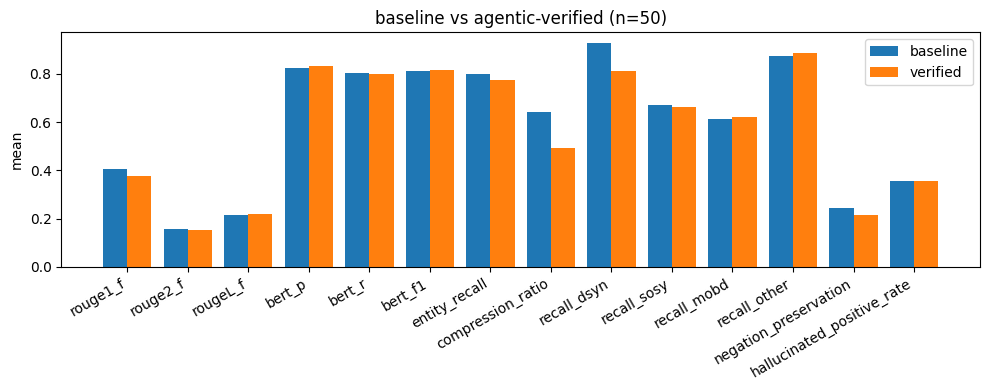


wrote /Users/natejly/Documents/GitHub/LLMS/benchmarks/results/mimic_ext_notes__qwen3.5-9b-4bit__verified__n50__20260420-115425.csv


In [11]:
if not RUN_AGENTIC_VERIFICATION or verified_summaries is None:
    print("agentic verification disabled; skipping comparison.")
else:
    import numpy as np
    import matplotlib.pyplot as plt

    verified_candidates = [verified_summaries[rid] for rid in ordered_row_ids]

    # Skip the expensive ROUGE/BERTScore/entity passes on summaries that the
    # verifier left unchanged: their metrics are byte-identical to baseline.
    # Only score the rows that actually changed, then splice them back in.
    baseline_paired_full = results_df.set_index('row_id').loc[ordered_row_ids]
    changed_mask = [
        verified_summaries[rid] != summaries[rid] for rid in ordered_row_ids
    ]
    changed_row_ids = [rid for rid, ch in zip(ordered_row_ids, changed_mask) if ch]
    changed_candidates = [verified_summaries[rid] for rid in changed_row_ids]
    changed_references = [
        ref for ref, ch in zip(references, changed_mask) if ch
    ]
    n_changed = len(changed_row_ids)
    n_total = len(ordered_row_ids)
    print(
        f"verified summary differs from baseline for {n_changed}/{n_total} notes; "
        f"recomputing metrics on the changed subset only."
    )

    def _verified_metric_df(metric_name, *, changed_values_by_rid, baseline_columns):
        rows = []
        for rid in ordered_row_ids:
            if rid in changed_values_by_rid:
                rows.append({'row_id': rid, **changed_values_by_rid[rid]})
            else:
                base = baseline_paired_full.loc[rid]
                rows.append({'row_id': rid, **{c: base[c] for c in baseline_columns}})
        return pd.DataFrame(rows)

    if n_changed:
        changed_rouge_rows = rouge_scores(changed_candidates, changed_references)
        changed_bert_rows = bertscore_pubmedbert(
            changed_candidates,
            changed_references,
            model_type=BERTSCORE_MODEL,
            batch_size=BERTSCORE_BATCH_SIZE,
            verbose=False,
        )
        changed_summaries_map = {
            rid: verified_summaries[rid] for rid in changed_row_ids
        }
        changed_entity_rows = entity_recall_per_note(
            changed_summaries_map, gold_pos_df, relaxed=RELAXED_ENTITY_MATCHER,
            semtype_buckets=SEMTYPE_BUCKETS,
        )
    else:
        changed_rouge_rows, changed_bert_rows, changed_entity_rows = [], [], []

    rouge_changed_map = {
        rid: {
            'rouge1_f': r.rouge1_f,
            'rouge2_f': r.rouge2_f,
            'rougeL_f': r.rougeL_f,
        }
        for rid, r in zip(changed_row_ids, changed_rouge_rows)
    }
    bert_changed_map = {
        rid: {
            'bert_p': b.precision,
            'bert_r': b.recall,
            'bert_f1': b.f1,
        }
        for rid, b in zip(changed_row_ids, changed_bert_rows)
    }
    # Reuse the same helper used for the baseline so verified rows have the
    # same per-semtype columns.
    entity_changed_flat = entity_rows_to_dataframe(
        changed_entity_rows, semtype_buckets=SEMTYPE_BUCKETS
    )
    entity_baseline_columns = entity_columns_for_semtypes(SEMTYPE_BUCKETS)
    entity_changed_map = {
        int(row['row_id']): {c: row[c] for c in entity_baseline_columns + ['missed_concepts']}
        for _, row in entity_changed_flat.iterrows()
    }

    verified_rouge_df = _verified_metric_df(
        'rouge',
        changed_values_by_rid=rouge_changed_map,
        baseline_columns=['rouge1_f', 'rouge2_f', 'rougeL_f'],
    )
    verified_bert_df = _verified_metric_df(
        'bert',
        changed_values_by_rid=bert_changed_map,
        baseline_columns=['bert_p', 'bert_r', 'bert_f1'],
    )
    verified_entity_df = _verified_metric_df(
        'entity',
        changed_values_by_rid=entity_changed_map,
        baseline_columns=entity_baseline_columns + ['missed_concepts'],
    )

    verified_results_df = (
        notes_df[['row_id', 'hadm_id', 'subject_id']]
        .merge(verified_rouge_df, on='row_id')
        .merge(verified_bert_df, on='row_id')
        .merge(verified_entity_df, on='row_id')
    )
    verified_results_df['summary_len_chars'] = verified_results_df['row_id'].map(
        lambda rid: len(verified_summaries.get(rid, ''))
    )
    verified_results_df['source_len_chars'] = notes_df.set_index('row_id').loc[
        verified_results_df['row_id'], 'text'
    ].str.len().values
    verified_results_df['compression_ratio'] = (
        verified_results_df['summary_len_chars'] / verified_results_df['source_len_chars']
    )

    # Recompute negation + hallucinated-positive for changed verified summaries;
    # carry baseline values over for unchanged rows.
    if neg_df is not None:
        if n_changed:
            changed_neg_rows = negation_preservation_per_note(
                {rid: verified_summaries[rid] for rid in changed_row_ids},
                gold_neg_df,
            )
            changed_halluc_rows = hallucinated_positive_per_note(
                {rid: verified_summaries[rid] for rid in changed_row_ids},
                gold_neg_df,
            )
        else:
            changed_neg_rows, changed_halluc_rows = [], []
        neg_changed_map: dict[int, dict] = {}
        for r in changed_neg_rows:
            neg_changed_map[r.row_id] = {
                'gold_negated_n': r.negated_n,
                'negation_preserved_n': r.preserved_n,
                'negation_preservation': r.rate,
            }
        for r in changed_halluc_rows:
            neg_changed_map.setdefault(r.row_id, {})
            neg_changed_map[r.row_id]['hallucinated_positive_n'] = r.hallucinated_n
            neg_changed_map[r.row_id]['hallucinated_positive_rate'] = r.rate
        neg_baseline_columns = [
            'gold_negated_n', 'negation_preserved_n', 'negation_preservation',
            'hallucinated_positive_n', 'hallucinated_positive_rate',
        ]
        verified_neg_df = _verified_metric_df(
            'neg',
            changed_values_by_rid=neg_changed_map,
            baseline_columns=neg_baseline_columns,
        )
        verified_results_df = verified_results_df.merge(
            verified_neg_df, on='row_id', how='left'
        )

    # Paired baseline vs verified rows on the same row_ids.
    baseline_paired = results_df.set_index('row_id').loc[ordered_row_ids]
    verified_paired = verified_results_df.set_index('row_id').loc[ordered_row_ids]

    compare_metric_cols = [
        'rouge1_f', 'rouge2_f', 'rougeL_f',
        'bert_p', 'bert_r', 'bert_f1',
        'entity_recall', 'compression_ratio',
    ]
    for _semtype in SEMTYPE_BUCKETS:
        _col = f'recall_{_semtype}'
        if _col in baseline_paired.columns and _col in verified_paired.columns:
            compare_metric_cols.append(_col)
    if neg_df is not None:
        for _col in ('negation_preservation', 'hallucinated_positive_rate'):
            if _col in baseline_paired.columns and _col in verified_paired.columns:
                compare_metric_cols.append(_col)

    def _bootstrap_ci(values, *, n_resamples=2000, alpha=0.05, seed=0):
        """Percentile bootstrap CI for the mean of a paired delta vector.

        NaN-safe: any pair where either baseline or verified is NaN is
        dropped before resampling (e.g. `recall_dsyn` is NaN for notes with
        zero dsyn-typed gold concepts).
        """
        rng = np.random.default_rng(seed)
        values = np.asarray(values, dtype=float)
        values = values[~np.isnan(values)]
        if len(values) == 0:
            return (float('nan'), float('nan'))
        idx = rng.integers(0, len(values), size=(n_resamples, len(values)))
        resampled_means = values[idx].mean(axis=1)
        return (
            float(np.quantile(resampled_means, alpha / 2)),
            float(np.quantile(resampled_means, 1 - alpha / 2)),
        )

    def _safe_mean(arr):
        arr = np.asarray(arr, dtype=float)
        mask = ~np.isnan(arr)
        return float(np.mean(arr[mask])) if mask.any() else float('nan')

    rows = []
    for col in compare_metric_cols:
        baseline_values = baseline_paired[col].to_numpy(dtype=float)
        verified_values = verified_paired[col].to_numpy(dtype=float)
        # For the paired delta, drop any note whose baseline OR verified is
        # NaN; averaging/CI over unpaired values would be misleading.
        pair_mask = ~np.isnan(baseline_values) & ~np.isnan(verified_values)
        delta_values = verified_values[pair_mask] - baseline_values[pair_mask]
        ci_low, ci_high = _bootstrap_ci(delta_values)
        rows.append(
            {
                'metric': col,
                'baseline_mean': _safe_mean(baseline_values),
                'verified_mean': _safe_mean(verified_values),
                'delta_mean': _safe_mean(delta_values),
                'n_paired': int(pair_mask.sum()),
                'delta_ci95_low': ci_low,
                'delta_ci95_high': ci_high,
            }
        )
    delta_df = pd.DataFrame(rows).round(4)
    print(f"=== {VERIFIED_MODEL_TAG} vs {MODEL_TAG} (n={len(ordered_row_ids)}) ===")
    print(delta_df.to_string(index=False))

    # Per-note comparison table joining baseline + verified per metric.
    comparison_df = baseline_paired[compare_metric_cols].add_suffix('_baseline').join(
        verified_paired[compare_metric_cols].add_suffix('_verified')
    )
    for col in compare_metric_cols:
        comparison_df[f'{col}_delta'] = (
            comparison_df[f'{col}_verified'] - comparison_df[f'{col}_baseline']
        )

    if verification_df is not None and len(verification_df):
        # Surface verification stats next to the deltas for context, including
        # initial-vs-final supported-claim counts and the support-rate lift
        # produced by the revision loop.
        verification_cols = [
            'n_passes', 'verified',
            'n_claims_initial', 'n_supported_initial',
            'n_unsupported_initial', 'support_rate_initial',
            'n_claims_final', 'n_supported_final',
            'n_unsupported_final', 'support_rate_final',
            'support_rate_delta',
        ]
        present_cols = [c for c in verification_cols if c in verification_df.columns]
        comparison_df = comparison_df.merge(
            verification_df.set_index('row_id')[present_cols],
            left_index=True,
            right_index=True,
            how='left',
        )
        # Also fold the support metrics into the verified results CSV so
        # downstream consumers can read them without parsing .verify.json.
        verified_results_df = verified_results_df.merge(
            verification_df[['row_id'] + present_cols],
            on='row_id',
            how='left',
        )

        # Print a compact "did revision help?" summary.
        deltas = verification_df['support_rate_delta'].dropna()
        if len(deltas):
            n_better = int((deltas > 0).sum())
            n_worse = int((deltas < 0).sum())
            n_same = int((deltas == 0).sum())
            print()
            print(
                f"support-rate delta over revision loop: "
                f"mean {deltas.mean():+.3f}  "
                f"({n_better} improved, {n_same} unchanged, {n_worse} regressed)"
            )

    # Grouped bar chart: baseline vs verified per metric.
    fig, ax = plt.subplots(figsize=(10, 4))
    bar_x = np.arange(len(compare_metric_cols))
    bar_width = 0.4
    ax.bar(
        bar_x - bar_width / 2,
        delta_df['baseline_mean'].to_numpy(),
        bar_width,
        label='baseline',
    )
    ax.bar(
        bar_x + bar_width / 2,
        delta_df['verified_mean'].to_numpy(),
        bar_width,
        label='verified',
    )
    ax.set_xticks(bar_x)
    ax.set_xticklabels(compare_metric_cols, rotation=30, ha='right')
    ax.set_ylabel('mean')
    ax.set_title(f'baseline vs agentic-verified (n={len(ordered_row_ids)})')
    ax.legend()
    fig.tight_layout()
    plt.show()

    # Save second results CSV mirroring the baseline naming convention.
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
    verified_out_path = (
        RESULTS_DIR
        / f"mimic_ext_notes__{VERIFIED_MODEL_TAG}__n{len(verified_results_df)}__{timestamp}.csv"
    )
    verified_results_df.to_csv(verified_out_path, index=False)
    print(f"\nwrote {verified_out_path}")